<a href="https://colab.research.google.com/github/rodrigorissettoterra/SENAI_Concepcao_e_Design_de_ML/blob/main/Classifica%C3%A7%C3%A3o_e_Regress%C3%A3o_com_Scikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ETAPA 1 - Regressão Linear

Prever a nota do aluno com base nas horas de estudo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

Gerar dados aleatórios

In [2]:
np.random.seed(42)

# 20 amostras de horas entre 1 e 8
horas = np.random.randint(1, 9, size=20)

# gerar notas com certa relação com horas de estudo + ruído
notas = horas * 1.1 + np.random.normal(0, 1.2, size=20)

# limitar as notas entre 0 e 10
notas = np.clip(notas, 0, 10)

# arredondar para 1 casa decimal
notas = np.round(notas, 1)

# criar dataframe
df = pd.DataFrame({
    "Horas": horas,
    "Nota": notas
})

print("Base de dados:")
print(df)

Base de dados:
    Horas  Nota
0       7   7.1
1       4   5.1
2       5   4.9
3       7   7.1
4       3   3.6
5       8   6.5
6       5   3.4
7       5   4.8
8       7   6.5
9       2   2.6
10      3   2.2
11      7   6.0
12      3   5.1
13      3   3.0
14      8   8.9
15      5   3.8
16      4   3.7
17      8   8.9
18      8   7.4
19      3   3.8


Separar variáveis

In [3]:
X = df[["Horas"]]
y = df["Nota"]

Treinar o modelo de regressão linear

In [4]:
modelo = LinearRegression()
modelo.fit(X, y)

LinearRegression()

Fazer predições

In [5]:
y_pred = modelo.predict(X)

Avaliar o modelo

In [6]:
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print("\nAvaliação do modelo:")
print("R²:", round(r2, 4))
print("MSE:", round(mse, 4))
print("RMSE:", round(rmse, 4))


Avaliação do modelo:
R²: 0.7947
MSE: 0.7833
RMSE: 0.885


Mostrar coeficientes da reta

In [7]:
print("\nEquação da reta:")
print(f"Nota = {modelo.coef_[0]:.4f} * Horas + {modelo.intercept_:.4f}")


Equação da reta:
Nota = 0.8612 * Horas + 0.6989


Visualização

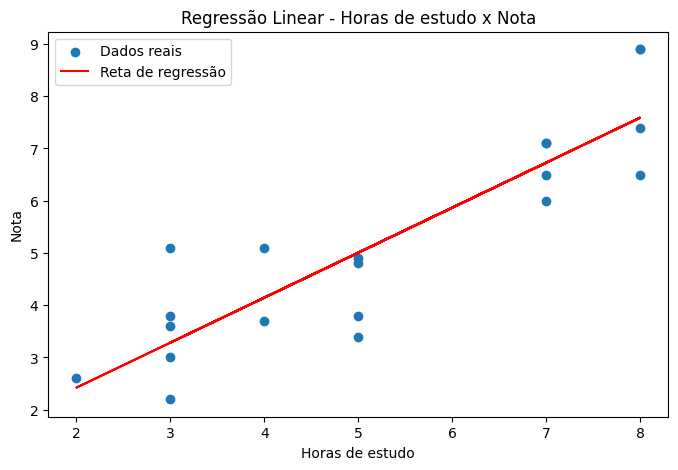

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label="Dados reais")
plt.plot(X, y_pred, color="red", label="Reta de regressão")
plt.xlabel("Horas de estudo")
plt.ylabel("Nota")
plt.title("Regressão Linear - Horas de estudo x Nota")
plt.legend()
plt.show()

Exemplo de previsão

In [9]:
nova_hora = pd.DataFrame({"Horas": [6]})
nota_prevista = modelo.predict(nova_hora)

print("\nExemplo de previsão:")
print("Para 6 horas de estudo, a nota prevista é:", round(nota_prevista[0], 2))


Exemplo de previsão:
Para 6 horas de estudo, a nota prevista é: 5.87


# ETAPA 2 - Classificação de fraude (PaySim)

In [10]:
import os
import numpy as np
import pandas as pd
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    AdaBoostClassifier,
    GradientBoostingRegressor,
    VotingClassifier
)

Download do dataset

In [11]:
path = kagglehub.dataset_download("ealaxi/paysim1")
print("Caminho do dataset:", path)

Using Colab cache for faster access to the 'paysim1' dataset.
Caminho do dataset: /kaggle/input/paysim1


Localizar o arquivo CSV

In [12]:
csv_path = None

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_path = os.path.join(root, file)
            break
    if csv_path is not None:
        break

if csv_path is None:
    raise FileNotFoundError("Nenhum arquivo CSV foi encontrado no dataset.")

print("CSV encontrado:", csv_path)

CSV encontrado: /kaggle/input/paysim1/PS_20174392719_1491204439457_log.csv


Carregar a base

In [13]:
df = pd.read_csv(csv_path)

print("\nShape original da base:")
print(df.shape)

print("\nPrimeiras linhas:")
print(df.head())


Shape original da base:
(6362620, 11)

Primeiras linhas:
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


Selecionar colunas relevantes

In [14]:
df = df[
    [
        "step",
        "type",
        "amount",
        "oldbalanceOrg",
        "newbalanceOrig",
        "oldbalanceDest",
        "newbalanceDest",
        "isFraud"
    ]
].copy()

print("\nShape após seleção de colunas:")
print(df.shape)


Shape após seleção de colunas:
(6362620, 8)


Transformar variável categórica em numérica

In [15]:
df = pd.get_dummies(df, columns=["type"], drop_first=True)

print("\nColunas após transformação:")
print(df.columns.tolist())


Colunas após transformação:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


Amostragem para facilitar execução no Colab

Como o dataset completo é muito grande, escolhi uma amostra para acelerar o treinamento.

In [16]:
amostra_tamanho = 20000
df_sample = df.sample(n=amostra_tamanho, random_state=42)

print("\nShape da amostra usada:")
print(df_sample.shape)

print("\nDistribuição da variável alvo:")
print(df_sample["isFraud"].value_counts())


Shape da amostra usada:
(20000, 11)

Distribuição da variável alvo:
isFraud
0    19963
1       37
Name: count, dtype: int64


Separar variáveis independentes e alvo

In [17]:
X = df_sample.drop("isFraud", axis=1)
y = df_sample["isFraud"]

Divisão treino/teste

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nFormato treino:", X_train.shape)
print("Formato teste:", X_test.shape)


Formato treino: (16000, 10)
Formato teste: (4000, 10)


Criação dos modelos

In [19]:
modelos = {
    "Decision Tree Classifier": DecisionTreeClassifier(random_state=42),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost Classifier": AdaBoostClassifier(random_state=42),

    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosted Trees Regressor": GradientBoostingRegressor(random_state=42)
}

resultados = {}

Treinar e avaliar os modelos

In [20]:
for nome, modelo in modelos.items():
    print(f"\nTreinando: {nome}")

    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    # Regressors retornam valores contínuos
    # Precisamos converter para 0 ou 1
    if "Regressor" in nome:
        y_pred = np.round(y_pred)
        y_pred = np.clip(y_pred, 0, 1).astype(int)

    acc = accuracy_score(y_test, y_pred)
    resultados[nome] = acc

    print(f"Acurácia de {nome}: {acc:.4f}")


Treinando: Decision Tree Classifier
Acurácia de Decision Tree Classifier: 0.9980

Treinando: Random Forest Classifier
Acurácia de Random Forest Classifier: 0.9995

Treinando: AdaBoost Classifier
Acurácia de AdaBoost Classifier: 0.9990

Treinando: Decision Tree Regressor
Acurácia de Decision Tree Regressor: 0.9980

Treinando: Random Forest Regressor
Acurácia de Random Forest Regressor: 0.9998

Treinando: Gradient Boosted Trees Regressor
Acurácia de Gradient Boosted Trees Regressor: 0.9990


Ensemble Classifier

In [21]:
ensemble = VotingClassifier(
    estimators=[
        ("dt", DecisionTreeClassifier(random_state=42)),
        ("rf", RandomForestClassifier(n_estimators=100, random_state=42)),
        ("ada", AdaBoostClassifier(random_state=42))
    ],
    voting="hard"
)

ensemble.fit(X_train, y_train)
y_pred_ensemble = ensemble.predict(X_test)

acc_ensemble = accuracy_score(y_test, y_pred_ensemble)
resultados["Ensemble Classifier"] = acc_ensemble

print(f"\nAcurácia de Ensemble Classifier: {acc_ensemble:.4f}")


Acurácia de Ensemble Classifier: 0.9995


Tabela final de resultados

In [22]:
df_resultados = pd.DataFrame(
    list(resultados.items()),
    columns=["Modelo", "Acuracia"]
).sort_values(by="Acuracia", ascending=False)

print("\nResultados finais:")
print(df_resultados)


Resultados finais:
                             Modelo  Acuracia
4           Random Forest Regressor   0.99975
6               Ensemble Classifier   0.99950
1          Random Forest Classifier   0.99950
5  Gradient Boosted Trees Regressor   0.99900
2               AdaBoost Classifier   0.99900
0          Decision Tree Classifier   0.99800
3           Decision Tree Regressor   0.99800


Melhor modelo

In [24]:
melhor_modelo = df_resultados.iloc[0]["Modelo"]
melhor_acuracia = df_resultados.iloc[0]["Acuracia"]

print("\nMelhor modelo encontrado:")
print(melhor_modelo)

print("\nMelhor acurácia:")
print(round(melhor_acuracia, 5))


Melhor modelo encontrado:
Random Forest Regressor

Melhor acurácia:
0.99975
